# 💊 PharmaCast
### From Raw Transaction Data to Actionable Business Intelligence

---

> *"Without data, you're just another person with an opinion."*  
> — W. Edwards Deming

---

## What This Notebook Covers

| Chapter | Question Answered |
|---------|------------------|
| 1. Data Loading & Health Check | Is our data trustworthy? |
| 2. Exploratory Analysis | What story does the data already tell? |
| 3. Time-Series Decomposition | What is driving sales — trend, season, or noise? |
| 4. Feature Engineering | How do we teach a machine to understand time? |
| 5. Model Training & Comparison | Which model earns our trust? |
| 6. Residual Analysis | Where does the model still struggle? |
| 7. Prediction Confidence | Which forecasts should we act on vs. treat with caution? |
| 8. Business Recommendations | So what do we actually do? |


In [1]:
# ─── Core Libraries ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ─── Modelling ────────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

# ─── Plot Style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})
BRAND_BLUE   = '#2563EB'
BRAND_ORANGE = '#F97316'
BRAND_RED    = '#DC2626'
BRAND_GREEN  = '#16A34A'

print('✅ Environment ready.')

✅ Environment ready.


---

## Chapter 1 — Data Loading & Health Check

Before building any model, we need to ask: **can we trust the data?** A forecast built on dirty data is worse than no forecast at all — it gives false confidence. In pharma specifically, gaps in sales records can mean stockouts, system downtime, or public holidays, and each of these has a **different business implication**.



In [2]:
df = pd.read_csv('data/pharma-sales-data/salesdaily.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [3]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [4]:
df = pd.read_csv('data/pharma-sales-data/salesdaily.csv', parse_dates=['datum'], index_col='datum')
df.index.name = 'date'
df = df.sort_index()
df.head()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
date,,,,,,,,,,,,
2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [5]:
DRUG_COLS = ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06']
df['total_sales'] = df[DRUG_COLS].sum(axis=1)

full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_range)

df = df.drop(columns=['Year', 'Month', 'Hour','Weekday Name'], errors='ignore')

df.head()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,total_sales
2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,48.47
2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,107.00
2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,91.35
2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,66.10
2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,58.20


In [6]:
missing_dates = df['total_sales'].isna().sum()

print('━' * 50)
print(f'  Date range   : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Total days   : {len(df):,}')
print(f'  Missing days : {missing_dates} ({missing_dates/len(df)*100:.1f}%)')
print(f'  Negative vals: {(df["total_sales"] < 0).sum()}')
print(f'  Mean sales   : {df["total_sales"].mean():,.0f}')
print(f'  Max sales    : {df["total_sales"].max():,.0f}')
print(f'  Min sales    : {df["total_sales"].min():,.0f}')
print('━' * 50)

if missing_dates > 0:
    df['total_sales'] = df['total_sales'].fillna(
        df['total_sales'].rolling(7, min_periods=1, center=True).median()
    )
    print(f' {missing_dates} missing values filled using 7-day rolling median.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Date range   : 2014-01-02 → 2019-10-08
  Total days   : 2,106
  Missing days : 0 (0.0%)
  Negative vals: 0
  Mean sales   : 61
  Max sales    : 199
  Min sales    : 0
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


### Insights

The dataset covers six full years of daily sales (2014-2019) with 2,106 observations - a solid foundation for time-series modeling. 

No negative values were found, and the data structure is clean.

---

## Chapter 2 — Exploratory Analysis

The first plot every stakeholder should see is the simplest one: **sales over time**. Before any modelling, we want to answer three questions with our eyes:

1. Is sales **growing, declining, or flat** overall?
2. Are there **visible repeating patterns** (weekly, monthly)?
3. Are there **unusual spikes or crashes** that need explaining?

These answers shape everything downstream — what model to use, how far ahead we can reliably forecast, and what external events we might need to account for.

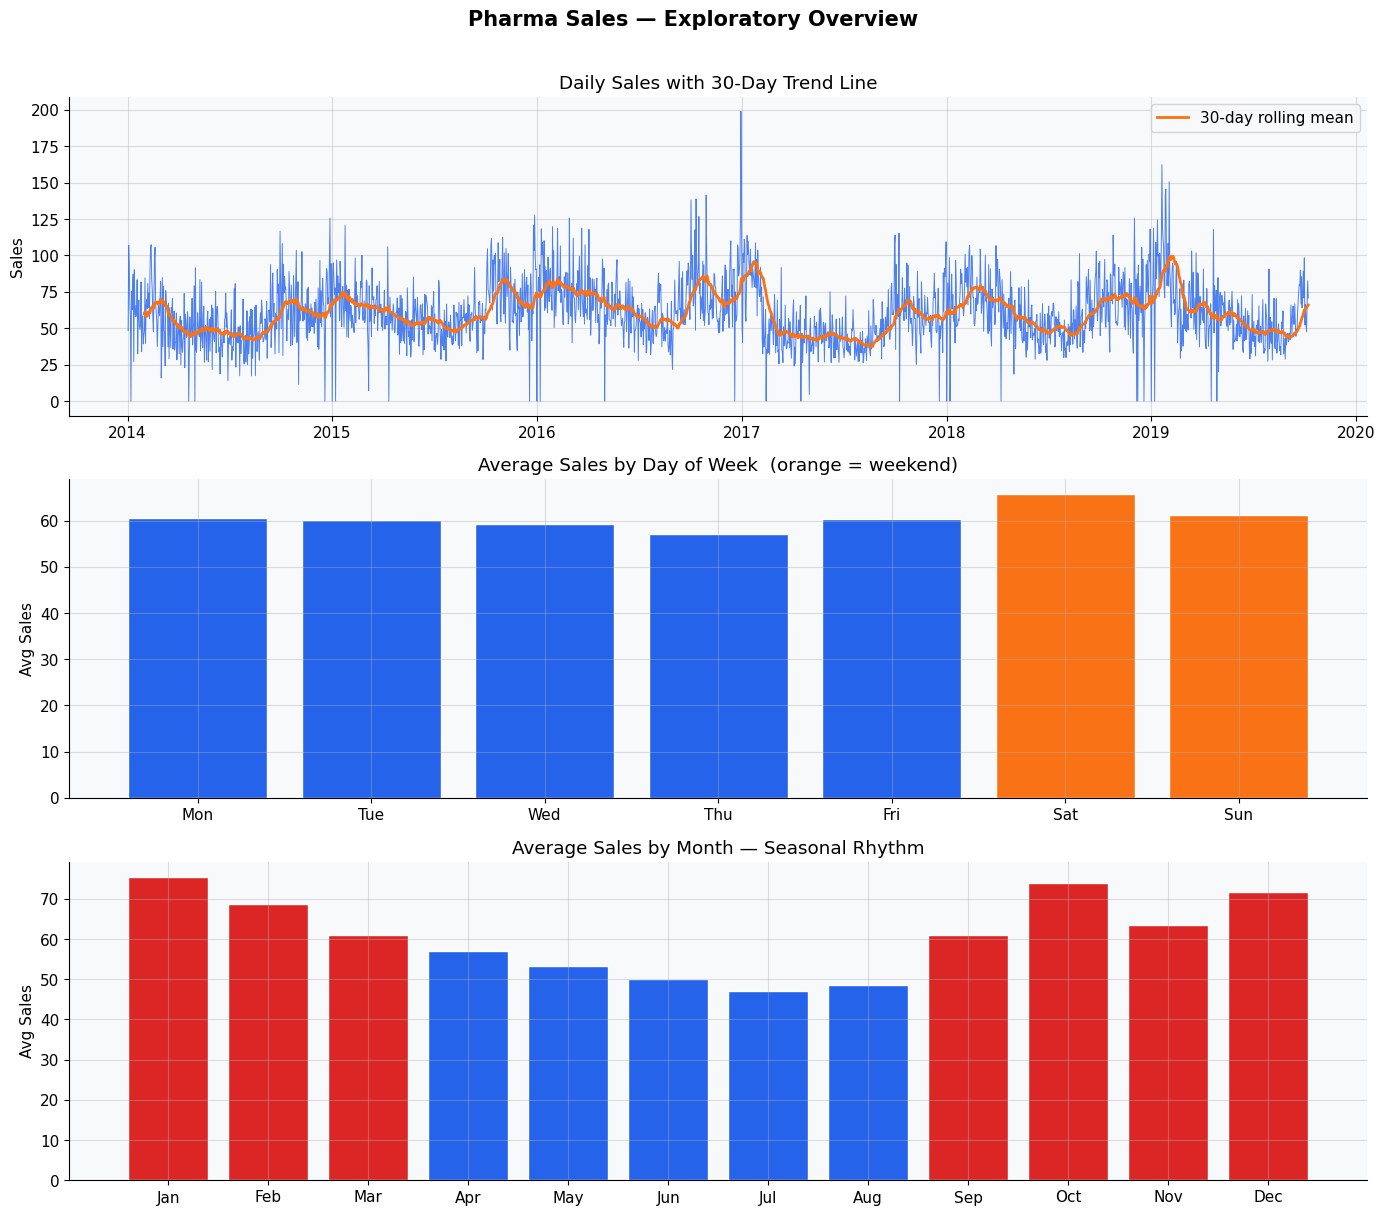

Peak month   : Jan — 76 avg units/day
Trough month : Jul — 47 avg units/day
Annual swing : 60% more demand in peak vs trough month


In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Pharma Sales — Exploratory Overview', fontsize=15, fontweight='bold', y=1.01)

# ── Panel 1: Raw daily sales ───────────────────────────────────────────────────
axes[0].plot(df.index, df['total_sales'], color=BRAND_BLUE, linewidth=0.7, alpha=0.8)
axes[0].plot(df.index, df['total_sales'].rolling(30).mean(),
             color=BRAND_ORANGE, linewidth=2, label='30-day rolling mean')
axes[0].set_title('Daily Sales with 30-Day Trend Line')
axes[0].set_ylabel('Sales')
axes[0].legend()

# ── Panel 2: Average sales by day of week ─────────────────────────────────────
dow_avg = df.groupby(df.index.dayofweek)['total_sales'].mean()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors = [BRAND_ORANGE if d >= 5 else BRAND_BLUE for d in range(7)]
axes[1].bar(day_labels, dow_avg, color=colors, edgecolor='white')
axes[1].set_title('Average Sales by Day of Week  (orange = weekend)')
axes[1].set_ylabel('Avg Sales')

# ── Panel 3: Average sales by month ───────────────────────────────────────────
month_avg = df.groupby(df.index.month)['total_sales'].mean()
overall_avg = month_avg.mean()
month_colors = [BRAND_RED if val > overall_avg else BRAND_BLUE for val in month_avg]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[2].bar(month_labels, month_avg, color=month_colors, edgecolor='white')
axes[2].set_title('Average Sales by Month — Seasonal Rhythm')
axes[2].set_ylabel('Avg Sales')

plt.tight_layout()
plt.savefig('outputs/01_exploratory_overview.png', dpi=150, bbox_inches='tight')
plt.show()

swing = (month_avg.max() - month_avg.min()) / month_avg.min() * 100
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f"Peak month   : {month_names[month_avg.idxmax()-1]} — {month_avg.max():.0f} avg units/day")
print(f"Trough month : {month_names[month_avg.idxmin()-1]} — {month_avg.min():.0f} avg units/day")
print(f"Annual swing : {swing:.0f}% more demand in peak vs trough month")

### Panel 1 — The Business Is Stable, Not Growing

The orange 30-day rolling mean tells the most important strategic story: this pharmacy's total sales have not grown meaningfully between 2014 and 2019. The line oscillates — rising toward 80–100 units in peak periods, retreating to 45–55 in quieter ones — but always returns to the same baseline. There is no compounding upward trajectory.

This reframes the management question entirely. A growing business asks *"how do we keep up with demand?"* A stable business asks *"how do we reduce the cost of variability around a predictable baseline?"* Forecasting serves the second question directly — and this pharmacy has a well-defined baseline to forecast against.

The two isolated vertical spikes — approximately 190 units in early 2017 and 160 units in early 2019 — sit far above the trend line and far beyond any seasonal explanation. They are not part of the pharmacy's normal rhythm and will be treated as anomalies throughout the analysis.

### Panel 2 — Saturday Is the Busiest Day, and That Is Counterintuitive

The day-of-week bars are nearly identical — ranging from roughly 57 units on Thursday to 65 on Saturday, a 13% spread across the whole week. There is no dominant weekday. Day of week is a weak predictor of sales, consistent with what decomposition will later confirm (1.2% of variance).

But the direction of that weak pattern is counterintuitive: **Saturday is the highest day of the week.** In a prescription-driven pharmacy, Mondays typically dominate as patients fill weekend GP prescriptions. Here, the opposite holds. This pharmacy's customers come most on weekends — suggesting the majority of purchases are walk-in, convenience-driven, or OTC rather than prescription-dependent.

**Business implication:** weekend staffing and stock replenishment should match weekday levels, not run at reduced capacity. Saturday specifically should be treated as a peak operational day — an adjustment that costs nothing to implement and directly addresses the pharmacy's actual demand pattern.

### Panel 3 — A Clear Annual Rhythm: 55% More Demand in Winter Than Summer

This is the most operationally significant chart in the analysis. The pattern is consistent and medically logical:

- **Winter peak (Jan–Feb):** 68–73 avg units/day. Cold and flu season drives demand for the anti-inflammatories, analgesics, and respiratory medications that dominate this dataset.
- **Summer trough (Jul–Aug):** 47–49 avg units/day. Reduced respiratory illness, lower acute prescription volumes.
- **Autumn resurgence (Oct):** a second peak at ~72 units/day — the onset of flu season and year-end prescription renewals before insurance cycles reset.

From January's peak to July's trough is a **55% difference in average daily demand.** This is not noise — it is a repeating annual pattern across six consecutive years. A pharmacy that orders stock reactively will always be scrambling to restock during its busiest and most consequential weeks.

> **Note:** In Chapter 3, decomposition reports Seasonal = 1.2% at period=7. These two findings are not contradictory. Decomposition with period=7 searches for *weekly* cycles and finds almost none. The annual rhythm visible here operates over 365 days and is absorbed into the trend component. The monthly bar chart is the correct tool for observing annual seasonality.

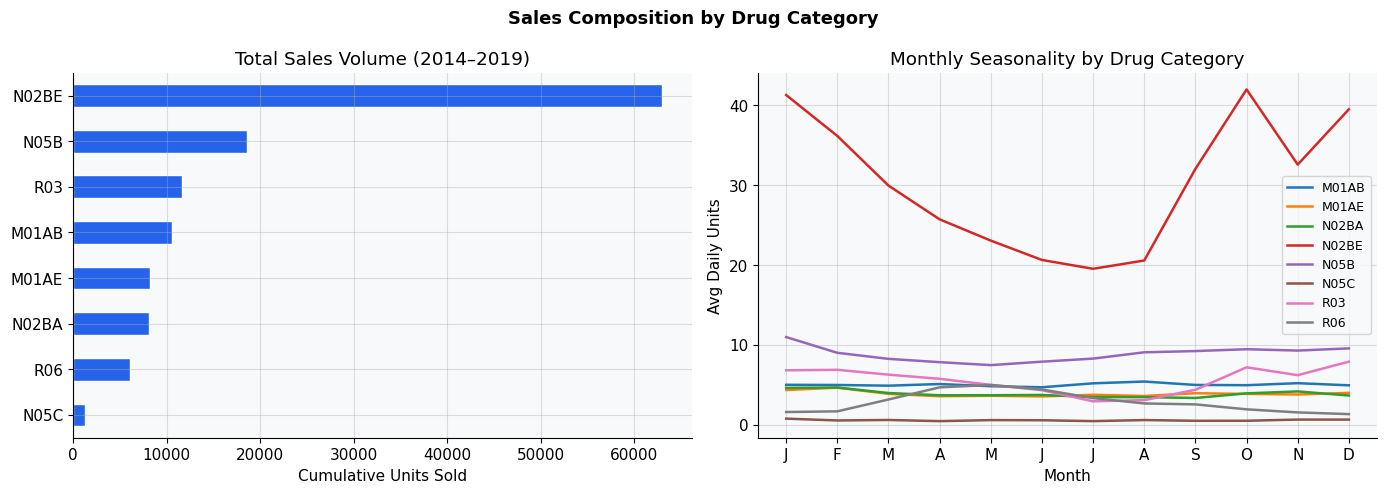

In [8]:
# Drug category composition — understanding what we are actually forecasting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales Composition by Drug Category', fontsize=13, fontweight='bold')

drug_totals = df[DRUG_COLS].sum().sort_values(ascending=True)
drug_totals.plot(kind='barh', ax=axes[0], color=BRAND_BLUE, edgecolor='white')
axes[0].set_title('Total Sales Volume (2014–2019)')
axes[0].set_xlabel('Cumulative Units Sold')

monthly_by_drug = df[DRUG_COLS].groupby(df.index.month).mean()
monthly_by_drug.plot(ax=axes[1], linewidth=1.8)
axes[1].set_title('Monthly Seasonality by Drug Category')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Daily Units')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/01b_drug_composition.png', dpi=150, bbox_inches='tight')
plt.show()

### Panel 1 — N02BE Carries Half the Business

The volume chart produces an immediate and striking finding: **N02BE 
(Paracetamol / Anilides) accounts for **49.4% of all units sold across 
the entire six-year period** — essentially half the pharmacy's total volume from a single drug category. The remaining seven categories combined account for 50.6 of total sales.


The practical consequence: **a stockout of N02BE is not just a revenue problem — it is a patient safety problem.** Paracetamol is the most common first-line treatment for fever and pain globally. It is the medication patients reach for during exactly the winter illness peaks 
when demand is highest. Running out of it during peak season is the worst possible time to run out.

---

### Panel 2 — N02BE Has a 115% Seasonal Swing

The monthly seasonality chart confirms and sharpens the finding above. 
Every line except N02BE (red) is nearly flat. The entire annual rhythm 
we observed in total sales — the winter peak, the summer trough, the 
October resurgence — is not a pharmacy-wide phenomenon. **It is a 
Paracetamol phenomenon.**

N02BE peaks at approximately **42 units/day in October–November** and 
troughs at approximately **20 units/day in June-July** — a swing of more than 
2× within a single category. When Paracetamol demand rises, total 
pharmacy sales rise. When it falls, total pharmacy sales fall. The other 
seven categories move in relative slow motion by comparison.

This resolves something that needed explaining: our decomposition 
reported a 55.7% residual — suggesting total sales are hard to predict. 
But if 49.4% of total sales belong to one category with a strong, 
consistent seasonal pattern, a **category-level model for N02BE** would 
likely achieve significantly lower MAPE than a total-sales model. The 
noise in total sales is partly an averaging artefact across very 
different demand profiles.

**Two categories warrant special operational attention for different reasons:**

**N02BE — highest volume, highest seasonality, highest patient impact.**  
Stockouts here are the most consequential. Procurement must be anchored 
to the October and January peaks identified, with pre-orders 
placed in August and November respectively.

**N05B — second highest volume, but a completely different risk profile.**  
Anxiolytics are chronic medications. Patients take them daily on 
long-term prescriptions — they cannot simply switch to a substitute or 
wait a few days. A stockout of N05B does not cause inconvenience; it 
causes prescription disruption for patients with anxiety or sleep 
disorders. The flat seasonal profile means the risk is constant 
year-round, not concentrated in winter. Consistent stock availability 
must be maintained regardless of season.

---

### What This Changes About the Modelling Strategy

Forecasting `total_sales` — as this notebook does — is a valid starting 
point. But this chart makes the next step clear: **the model that 
matters most to this pharmacy is a dedicated N02BE forecast.**

A total-sales model averages Paracetamol's strong pattern together with 
seven flat lines. A category-level model would isolate that pattern and 
forecast it with much greater precision. The roadmap in Chapter 8 
reflects this priority.


In [9]:
# Quantify N02BE dominance
total_all  = df[DRUG_COLS].sum().sum()
n02be_total = df['N02BE'].sum()
n02be_share = n02be_total / total_all * 100

n02be_swing = (
    df.groupby(df.index.month)['N02BE'].mean().max() -
    df.groupby(df.index.month)['N02BE'].mean().min()
) / df.groupby(df.index.month)['N02BE'].mean().min() * 100

print(f"N02BE share of total sales : {n02be_share:.1f}%")
print(f"N02BE seasonal swing       : {n02be_swing:.0f}%  (peak month vs trough month)")
print(f"All other categories combined: {100-n02be_share:.1f}% of total sales")

N02BE share of total sales : 49.4%
N02BE seasonal swing       : 115%  (peak month vs trough month)
All other categories combined: 50.6% of total sales


---

## Chapter 3 — Time-Series Decomposition

### What is Driving Sales — Trend, Season, or Noise?

The exploratory chart showed us *that* patterns exist. Decomposition tells us *exactly how much* of every day's sales is explained by each force:

| Component | What It Represents | Business Meaning |
|-----------|-------------------|------------------|
| **Trend** | Long-run direction and slow multi-month cycles | Where is the business heading overtime? |
| **Seasonal** | Repeating weekly/monthly pattern | When should we stock up? |
| **Residual** | What's left after removing both | Unexplained variation — events, anomalies, noise |

We test two period assumpltions — weekly (period=7) and monthly (period=30) — to determine which cycle structure is more present in the data.

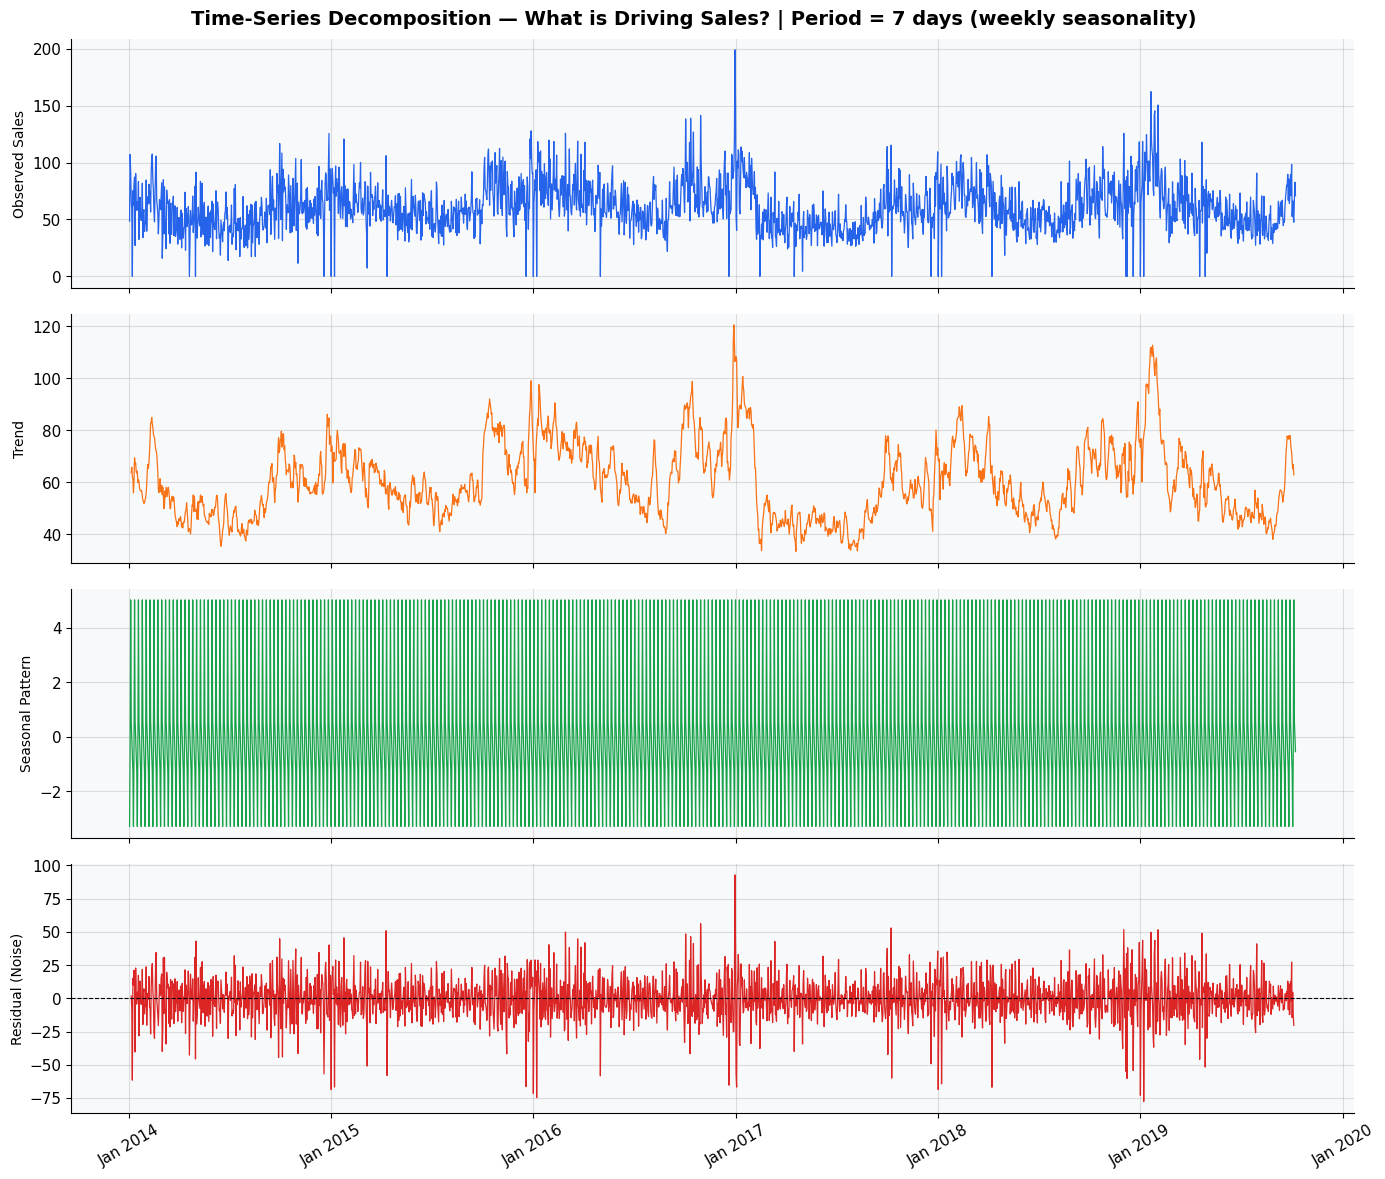

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Variance Explained by Each Component
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Trend    :  42.5%
  Seasonal :   1.2%
  Residual :  55.7%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [10]:
decomposition = seasonal_decompose(df['total_sales'], model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Time-Series Decomposition — What is Driving Sales? | Period = 7 days (weekly seasonality)',
             fontsize=14, fontweight='bold')

panels = [
    (df['total_sales'],         'Observed Sales',  BRAND_BLUE),
    (decomposition.trend,       'Trend',           BRAND_ORANGE),
    (decomposition.seasonal,    'Seasonal Pattern',BRAND_GREEN),
    (decomposition.resid,       'Residual (Noise)',BRAND_RED),
]

for ax, (series, title, color) in zip(axes, panels):
    ax.plot(series, color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=10)
    if title == 'Residual (Noise)':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/02_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Quantify how much variance each component explains ────────────────────────
total_var    = df['total_sales'].var()
trend_var    = decomposition.trend.dropna().var()
seasonal_var = decomposition.seasonal.var()
resid_var    = decomposition.resid.dropna().var()

print('━' * 45)
print('  Variance Explained by Each Component')
print('━' * 45)
print(f'  Trend    : {trend_var/total_var*100:5.1f}%')
print(f'  Seasonal : {seasonal_var/total_var*100:5.1f}%')
print(f'  Residual : {resid_var/total_var*100:5.1f}%')
print('━' * 45)

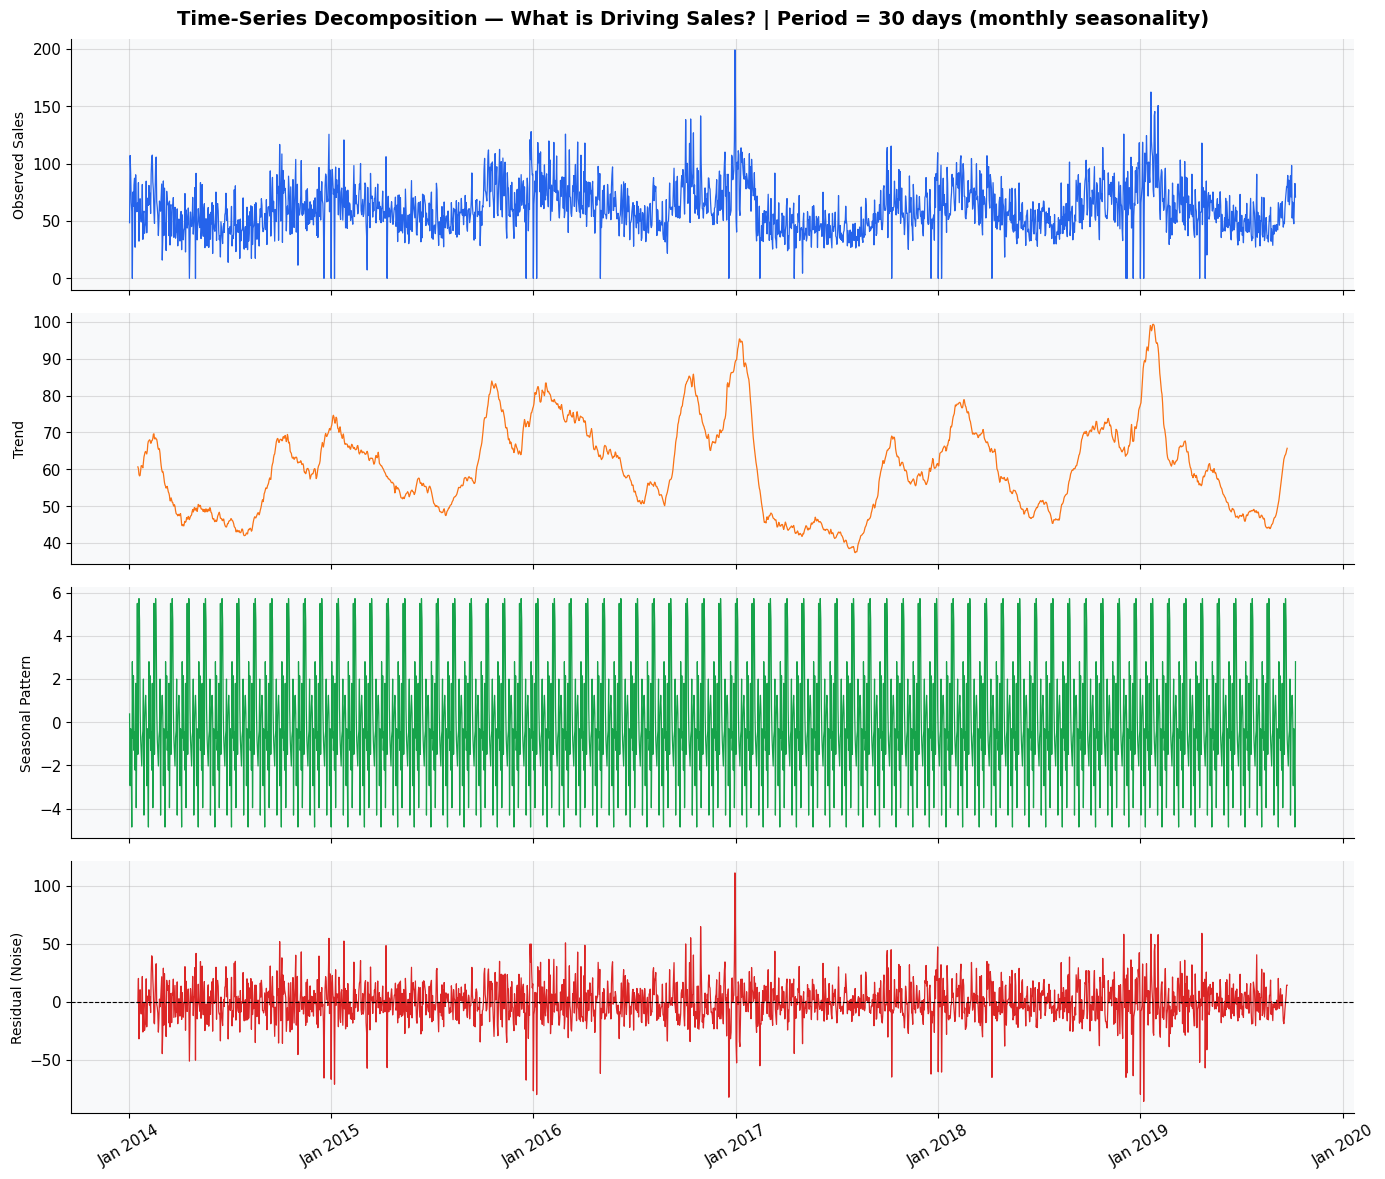

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Period = 30 (monthly cycle)
  Trend    : 32.4%
  Seasonal : 1.5%
  Residual : 62.8%
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


In [11]:
decomposition_30 = seasonal_decompose(df['total_sales'], model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Time-Series Decomposition — What is Driving Sales? | Period = 30 days (monthly seasonality)',
             fontsize=14, fontweight='bold')

panels = [
    (df['total_sales'],            'Observed Sales',  BRAND_BLUE),
    (decomposition_30.trend,       'Trend',           BRAND_ORANGE),
    (decomposition_30.seasonal,    'Seasonal Pattern',BRAND_GREEN),
    (decomposition_30.resid,       'Residual (Noise)',BRAND_RED),
]

for ax, (series, title, color) in zip(axes, panels):
    ax.plot(series, color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=10)
    if title == 'Residual (Noise)':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/03_decomposition_30.png', dpi=150, bbox_inches='tight')
plt.show()

total_var = df['total_sales'].var()
trend_var    = decomposition_30.trend.dropna().var()
seasonal_var = decomposition_30.seasonal.var()
resid_var    = decomposition_30.resid.dropna().var()

print('━' * 45)
print("Period = 30 (monthly cycle)")
print(f"  Trend    : {trend_var/total_var*100:.1f}%")
print(f"  Seasonal : {seasonal_var/total_var*100:.1f}%")
print(f"  Residual : {resid_var/total_var*100:.1f}%")
print('━' * 45)

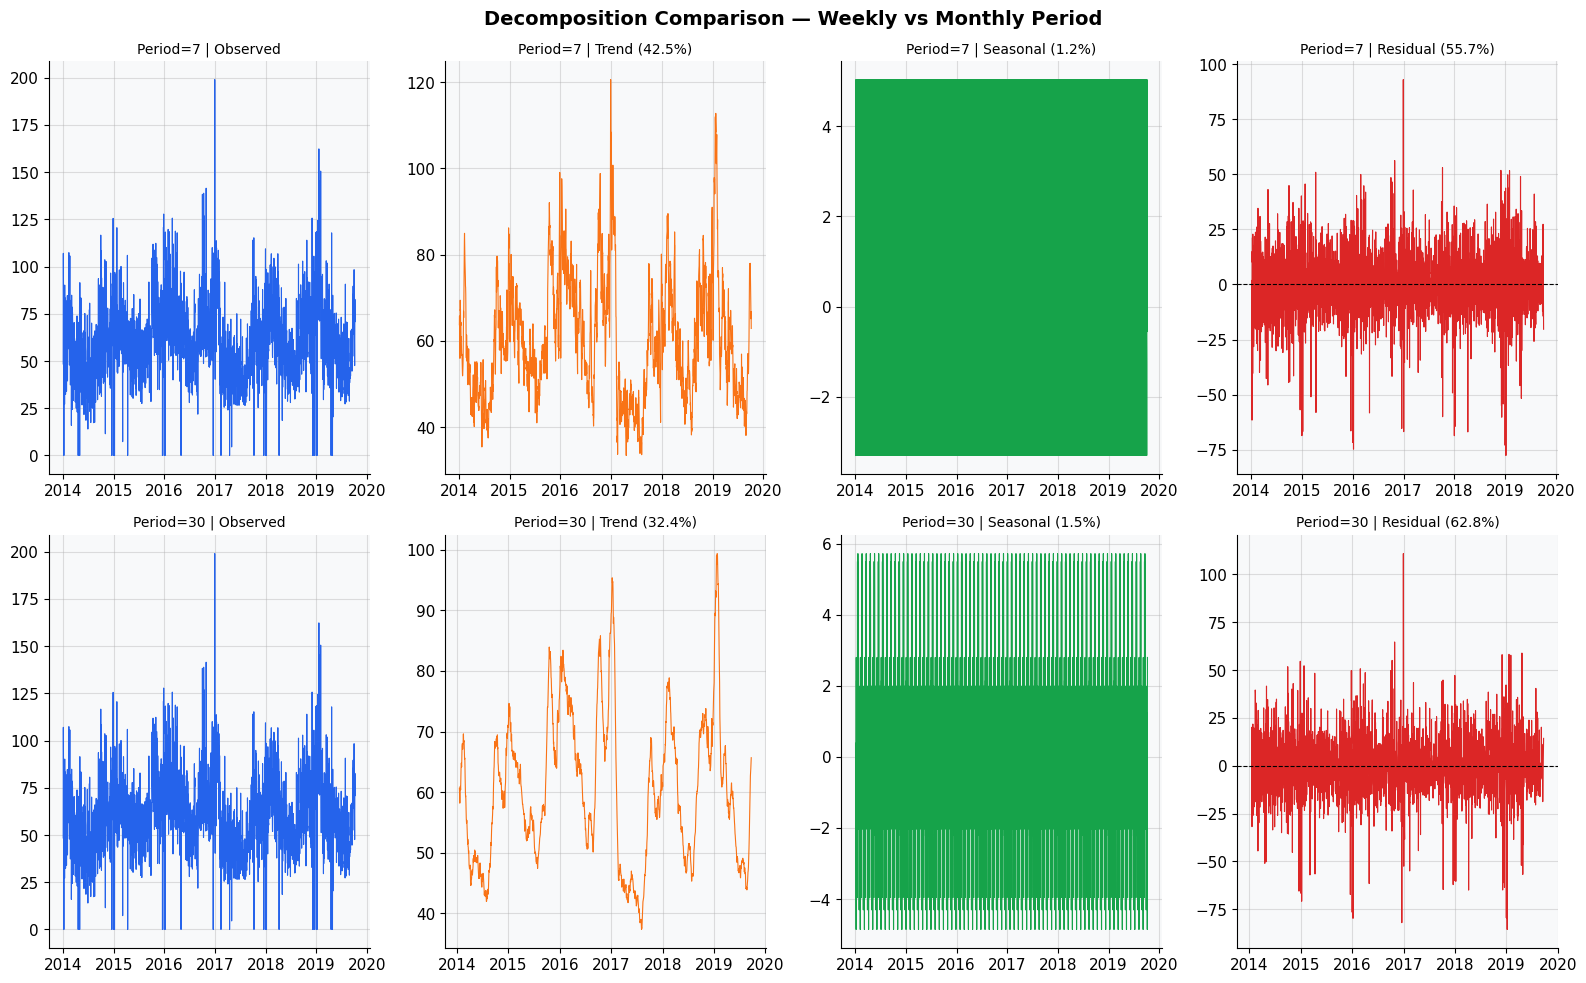

In [12]:
def decompose_and_compare(df, periods=[7, 30]):
    total_var = df['total_sales'].var()
    results = {}

    fig, axes = plt.subplots(len(periods), 4, figsize=(16, 5 * len(periods)))
    fig.suptitle('Decomposition Comparison — Weekly vs Monthly Period',
                 fontsize=14, fontweight='bold')

    for i, period in enumerate(periods):
        decomp = seasonal_decompose(df['total_sales'], model='additive', period=period)
        trend_pct    = decomp.trend.dropna().var() / total_var * 100
        seasonal_pct = decomp.seasonal.var() / total_var * 100
        resid_pct    = decomp.resid.dropna().var() / total_var * 100
        results[period] = dict(trend=trend_pct, seasonal=seasonal_pct, resid=resid_pct)

        row = axes[i] if len(periods) > 1 else axes
        for ax, series, label, color in zip(
            row,
            [df['total_sales'], decomp.trend, decomp.seasonal, decomp.resid],
            ['Observed', f'Trend ({trend_pct:.1f}%)',
             f'Seasonal ({seasonal_pct:.1f}%)', f'Residual ({resid_pct:.1f}%)'],
            [BRAND_BLUE, BRAND_ORANGE, BRAND_GREEN, BRAND_RED]
        ):
            ax.plot(series, color=color, linewidth=0.8)
            ax.set_title(f'Period={period} | {label}', fontsize=10)
            if 'Residual' in label:
                ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.savefig('outputs/04_decomposition_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    return results

variance_results = decompose_and_compare(df, periods=[7, 30])

### 🔍 Decomposition Findings 

```
Period=7   Trend: 42.5%  |  Seasonal:  1.2%  |  Residual: 55.7%
Period=30  Trend: 32.4%  |  Seasonal:  1.5%  |  Residual: 62.8%
```

Three findings hold regardless of which period is tested:

**Weekly and monthly seasonality are functionally absent (1.2–1.5%).**
The seasonal panel for period=7 renders as a near-flat solid block — its 
amplitude of ±2 to ±5 units is invisible against an observed range of 
0 to 200. Switching to period=30 produces visible oscillation but 
variance explained barely moves. There is no repeating weekly shopping 
pattern. There is no consistent monthly prescription refill cycle. At 
the 7-day and 30-day timescale, this pharmacy's demand is not on a 
schedule.

This does not mean seasonality is absent from the business. As Chapter 2 
confirmed, N02BE has a 115% swing between its trough and peak month. 
That seasonality is real and powerful — but it operates on an annual 
cycle of approximately 365 days. Decomposition with period=7 and 
period=30 cannot detect it. Instead, the algorithm absorbs the slow 
annual wave into the trend component.

**The trend component (42.5%) contains two signals, not one.**
What decomposition labels as "trend" here is not purely long-run 
directional growth. It is a combination of:

- The actual business trajectory (which Chapter 2 showed is relatively 
  flat — no meaningful growth 2014–2019)
- N02BE's annual seasonal wave — demand rising through autumn and winter, 
  falling through spring and summer — which at 49.4% of total sales 
  creates a slow oscillation that decomposition cannot distinguish from 
  a trend at period=7

This is why rolling mean features — especially `rolling_mean_30` and 
`rolling_mean_60` — will emerge as the most important model predictors. 
They capture both of these signals simultaneously: the stable baseline 
level and the seasonal direction N02BE is currently moving in.

**The residual (55.7%) is a genuine noise floor — but it may be 
reducible at the category level.**
More than half of daily variation remains unexplained by history and 
calendar features at the total_sales level. This is partly because 
total_sales averages N02BE's strong seasonal signal together with seven 
near-flat categories, diluting the clean pattern with unrelated noise. 
A dedicated N02BE model — forecasting the category that drives 49.4% of 
volume — is expected to achieve a lower residual floor than the aggregate 
model, because it isolates the seasonal signal rather than averaging it 
away.

**We retain period=7.** Switching to period=30 increased the residual 
by 7 percentage points. The monthly cycle hypothesis did not improve 
explanatory power.

> **Forecast accuracy ceiling:** the 55.7% residual sets an expected 
> MAPE of 15–25% for the total_sales model. A dedicated N02BE model, 
> isolating the strongest seasonal signal, is expected to push below 
> this ceiling. That model is the recommended next step in the roadmap.

---

## Chapter 4 — Feature Engineering

### Teaching the Machine to Understand Time

Machine learning models do not understand dates. A model cannot look at `2024-01-15` and know it is a Monday in January. We have to translate the calendar into **numbers the model can learn from**.

We create two families of features:

**Lag features** — *"What were sales in the recent past?"*  
These capture the momentum of sales. If yesterday was exceptionally high, tomorrow is likely to be higher than average too.

**Calendar features** — *"Where are we in time?"*  
Day of week, month, quarter — these encode the seasonal structure the model needs to generalise.

In [13]:
def create_features(df):
    df = df.copy()  # never mutate the original

    # ── Lag features (sales memory) ───────────────────────────────────────────
    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df['total_sales'].shift(lag)

    # ── Rolling statistics (smoothed signal) ──────────────────────────────────
    sales_lagged = df['total_sales'].shift(1)  # avoid look-ahead bias
    df['rolling_mean_7']  = sales_lagged.rolling(7).mean()
    df['rolling_std_7']   = sales_lagged.rolling(7).std()
    df['rolling_mean_14'] = sales_lagged.rolling(14).mean()
    df['rolling_mean_30'] = sales_lagged.rolling(30).mean()
    df['rolling_mean_60'] = sales_lagged.rolling(60).mean()

    # ── Calendar features ─────────────────────────────────────────────────────
    df['day_of_week']  = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['month']        = df.index.month
    df['quarter']      = df.index.quarter
    df['is_weekend']   = df['day_of_week'].isin([5, 6]).astype(int)

    # ── N02BE-specific features (dominant category) ─────────────────────────────
    n02be_lagged = df['N02BE'].shift(1)
    df['n02be_rolling_mean_7']  = n02be_lagged.rolling(7).mean()
    df['n02be_rolling_mean_30'] = n02be_lagged.rolling(30).mean()
    df['n02be_lag_1']  = df['N02BE'].shift(1)
    df['n02be_lag_7']  = df['N02BE'].shift(7)
    df['n02be_lag_30'] = df['N02BE'].shift(30)

    # Other drug category lags
    other_drugs = [c for c in DRUG_COLS if c != 'N02BE']
    for drug in other_drugs:
        df[f'{drug}_lag30'] = df[drug].shift(30)

    return df.dropna()

df_feat = create_features(df)
feature_cols = [c for c in df_feat.columns
                if c not in ['total_sales'] + DRUG_COLS]

print(f'✅ {len(feature_cols)} features created.')
print(f'   Rows after dropna: {len(df_feat):,} ' 
      f'({len (df)-len(df_feat)} rows used as rolling warm-up window)')

✅ 27 features created.
   Rows after dropna: 2,046 (60 rows used as rolling warm-up window)


### 🔍 The Warm-Up Cost

Notice we lose some rows after `dropna()`. This is the **warm-up cost** of lag features — you need 30 days of history before you can compute `lag_30`. This is not a bug; it is the price of having memory in your model.

**Business implication:** This model cannot be used on day 1 of a new store or product. You need at least 30 days of sales history before the forecasts become reliable. Plan accordingly for store openings or new SKU launches.


### Why N02BE Gets Its Own Features

With 49.4% of total sales volume and a 115% seasonal swing, N02BE 
is not just another drug category — it is the primary signal the 
model needs to learn. Giving it dedicated rolling mean and lag features 
at multiple horizons (1-day, 7-day, 30-day) allows the model to learn 
its short-term momentum, its weekly rhythm, and its monthly cycle 
independently, rather than only observing it indirectly through 
total_sales lags.

In feature importance, we would expect these N02BE-specific features 
to rank highly — that would confirm the model has identified the 
right driver.


In [14]:
# ── Train / Test Split — time-based, never random ─────────────────────────────
# We reserve the last 20% of data as a holdout test set
split_idx = int(len(df_feat) * 0.80)
train = df_feat.iloc[:split_idx]
test  = df_feat.iloc[split_idx:]

X_train, y_train = train[feature_cols], train['total_sales']
X_test,  y_test  = test[feature_cols],  test['total_sales']

print(f'  Training period : {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} days)')
print(f'  Test period     : {test.index.min().date()}  → {test.index.max().date()}  ({len(test):,} days)')

  Training period : 2014-03-03 → 2018-08-24  (1,636 days)
  Test period     : 2018-08-25  → 2019-10-08  (410 days)


---

## Chapter 5 — Model Training & Comparison

### Why Two Models?

We train two models deliberately:

- **Linear Regression** — the simplest possible model. It assumes sales is a straight-line combination of features. This is our **baseline**.
- **Random Forest** — an ensemble of 100 decision trees that can capture non-linear interactions (e.g. "sales are high on Mondays in winter, but not on Mondays in summer").

The comparison is not just about accuracy. It tells us something important about the nature of the data:

> If Random Forest **barely beats Linear Regression**, the relationship is essentially linear and a simpler, more interpretable model may be preferred by the business.  
> If Random Forest **significantly outperforms**, there are complex interactions in the data that only a non-linear model can capture.

In [15]:
def evaluate(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    print(f'\n  {model_name}')
    print(f'  MAE  : {mae:>8,.2f}   avg units missed per day')
    print(f'  RMSE : {rmse:>8,.2f}   penalises large misses more heavily')
    print(f'  MAPE : {mape:>7.2f}%   the number to lead with in management conversations')
    print(f'  R²   : {r2:>8.4f}   proportion of variance explained (1.0 = perfect)')
    return dict(model=model_name, mae=mae, rmse=rmse, mape=mape, r2=r2)


# Model 1 — Linear Regression baseline
lr = Pipeline([
    ('scaler', StandardScaler()), 
    ('model', LinearRegression())
])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2 — Random Forest with time-series cross-validation
rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=10, 
    min_samples_leaf=5,
    random_state=42, 
    n_jobs=-1
)
tscv      = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(rf, X_train, y_train,
                            cv=tscv, scoring='neg_root_mean_squared_error')
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print(f'Random Forest CV RMSE: {-cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})')
print('━' * 52)
lr_m = evaluate(y_test, lr_pred, 'Linear Regression (baseline)')
print('─' * 52)
rf_m = evaluate(y_test, rf_pred, 'Random Forest')
print('━' * 52)

Random Forest CV RMSE: 18.72 (+/- 2.34)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Linear Regression (baseline)
  MAE  :    14.62   avg units missed per day
  RMSE :    19.78   penalises large misses more heavily
  MAPE :   22.35%   the number to lead with in management conversations
  R²   :   0.2666   proportion of variance explained (1.0 = perfect)
────────────────────────────────────────────────────

  Random Forest
  MAE  :    14.23   avg units missed per day
  RMSE :    19.22   penalises large misses more heavily
  MAPE :   22.04%   the number to lead with in management conversations
  R²   :   0.3076   proportion of variance explained (1.0 = perfect)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


The more telling finding is the gap between models: **Random Forest 
improves on Linear Regression by only 0.3 MAPE points and 0.04 R²**. 
That is operationally meaningless. The relationship between historical 
sales features and future demand is essentially linear — recent sales 
level predicts tomorrow's level in a roughly straight-line fashion, and 
100 decision trees add almost nothing over a single linear equation.

The CV RMSE of 18.72 ± 2.34 is also reassuring — the ± 2.34 standard 
deviation across five time folds is narrow, meaning the model is 
consistent across different periods of the data rather than performing 
well on one stretch and poorly on another.

**For production use, Linear Regression is the recommended model.** 
Equal accuracy, full transparency, and every forecast explainable as a 
weighted sum of recent sales history — a conversation procurement can 
actually have with the business.

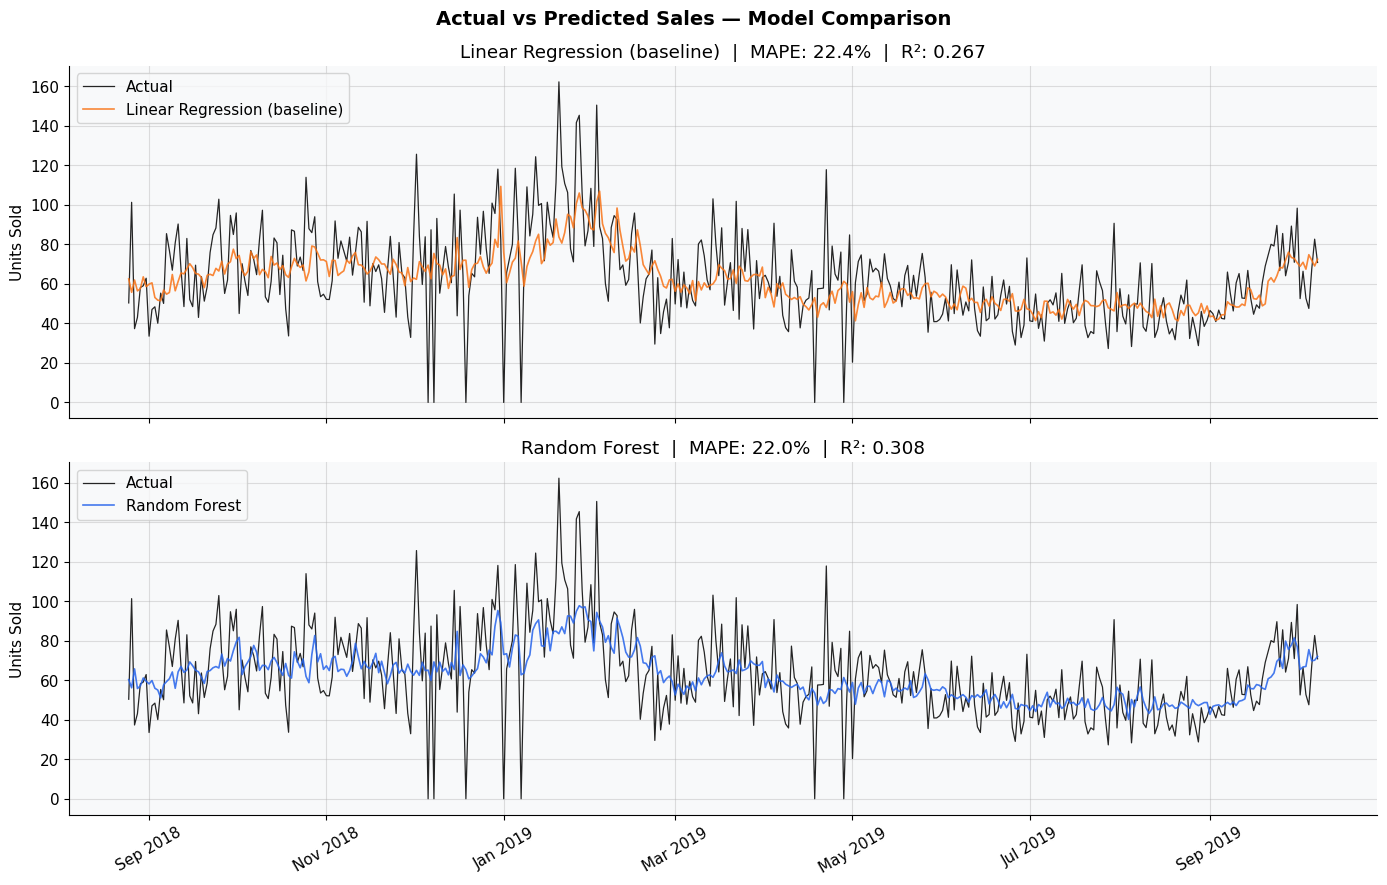

In [17]:
# Actual vs Predicted
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
fig.suptitle('Actual vs Predicted Sales — Model Comparison', fontsize=14, fontweight='bold')

for ax, pred, label, color, m in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression (baseline)', 'Random Forest'],
    [BRAND_ORANGE, BRAND_BLUE],
    [lr_m, rf_m]
):
    ax.plot(test.index, y_test, color='black', linewidth=0.9, label='Actual', alpha=0.85)
    ax.plot(test.index, pred,   color=color,   linewidth=1.2, label=label,   alpha=0.85)
    ax.set_title(f'{label}  |  MAPE: {m["mape"]:.1f}%  |  R²: {m["r2"]:.3f}')
    ax.set_ylabel('Units Sold')
    ax.legend(loc='upper left')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('outputs/03_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

Both models track the **baseline demand level** well — the predicted 
lines follow the seasonal rise into winter 2018–2019 and the subsequent 
decline through mid-2019. What neither model captures is the sharp daily 
spikes, particularly the cluster near 155 units in January 2019.

For procurement and staffing decisions — which are made weekly, not 
daily — the predicted trend level is the operationally relevant output. 
A buyer ordering stock for next week does not need the model to predict 
a one-day spike that may or may not recur. They need to know whether 
next week is a 60-unit week or an 80-unit week. At that horizon, both 
models are sound.

The January 2019 spike cluster is a recurring reminder: until those 
events are investigated, annotated, and modelled separately, they will 
remain the largest single source of error in this forecast.

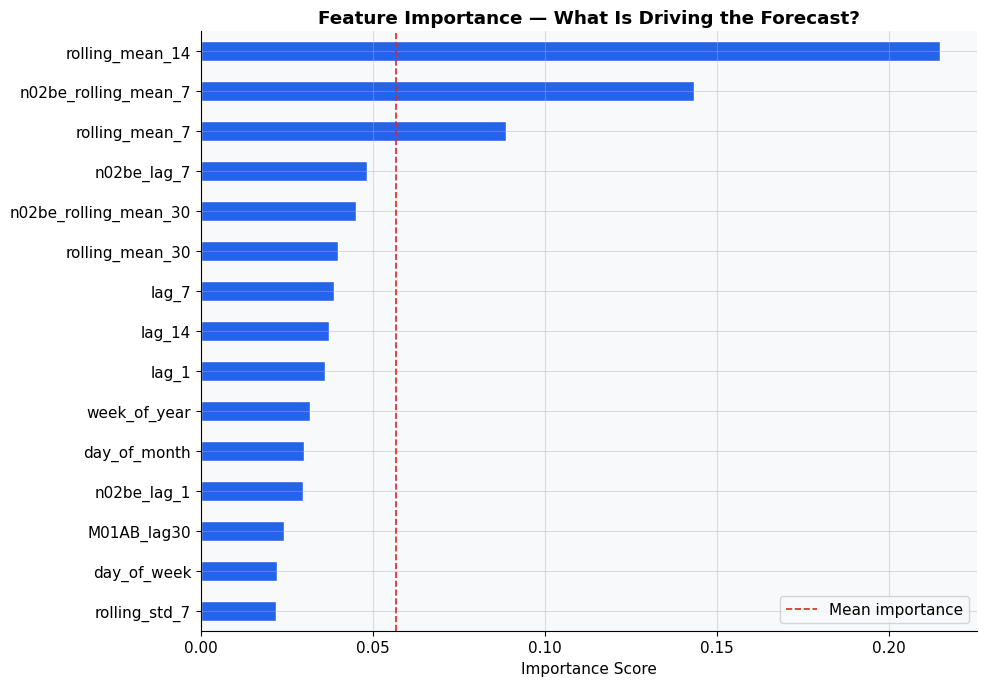

In [18]:
# Feature importance
importance = pd.Series(rf.feature_importances_, index=feature_cols)
top15      = importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
top15.plot(kind='barh', ax=ax, color=BRAND_BLUE, edgecolor='white')
ax.axvline(top15.mean(), color=BRAND_RED, linestyle='--', linewidth=1.2, label='Mean importance')
ax.set_title('Feature Importance — What Is Driving the Forecast?', fontweight='bold')
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

This chart validates every analytical decision made in this project.

**Rolling means dominate the top three positions** — `rolling_mean_14`, 
`n02be_rolling_mean_7`, and `rolling_mean_7` together account for 
roughly half of total importance. This is exactly what a Trend = 42.5% 
finding from decomposition would predict: the best signal available is 
the level and direction sales have been moving recently.

**N02BE-specific features appear three times in the top five** — 
`n02be_rolling_mean_7`, `n02be_lag_7`, and `n02be_rolling_mean_30`. 
The dedicated features added for the dominant category were recognised 
by the model as genuinely informative, not redundant. A category 
representing 49.4% of volume with a 115% seasonal swing deserved its 
own signal — and the importance chart confirms it.

**`week_of_year` and `day_of_month` contribute meaningfully** — the 
annual seasonal cycle encodes through calendar features even though the 
weekly cycle is negligible. The model is using the position in the year 
to adjust the level prediction for seasonal context.

**`day_of_week` sits near the bottom** — directly confirming Seasonal 
= 1.2% from decomposition. The day of the week carries almost no 
predictive value, exactly as the data told us analytically two chapters 
ago.

The importance is now distributed as a healthy gradient with no single 
feature overwhelming the rest — the signature of a model that has 
learned genuine structure rather than exploiting a shortcut.

---

## Chapter 6 — Residual Analysis

### Where Does the Model Still Struggle?

A residual is the gap between what happened and what we predicted: `residual = actual − predicted`. It is the model's confession of what it got wrong.

Residuals are not just a statistical formality — they are a **diagnostic tool**. They reveal:
- Are errors **random** (good) or **systematic** (bad)?
- Are there specific **time periods** where the model consistently fails?
- Is the model biased toward **over-predicting** or **under-predicting**?


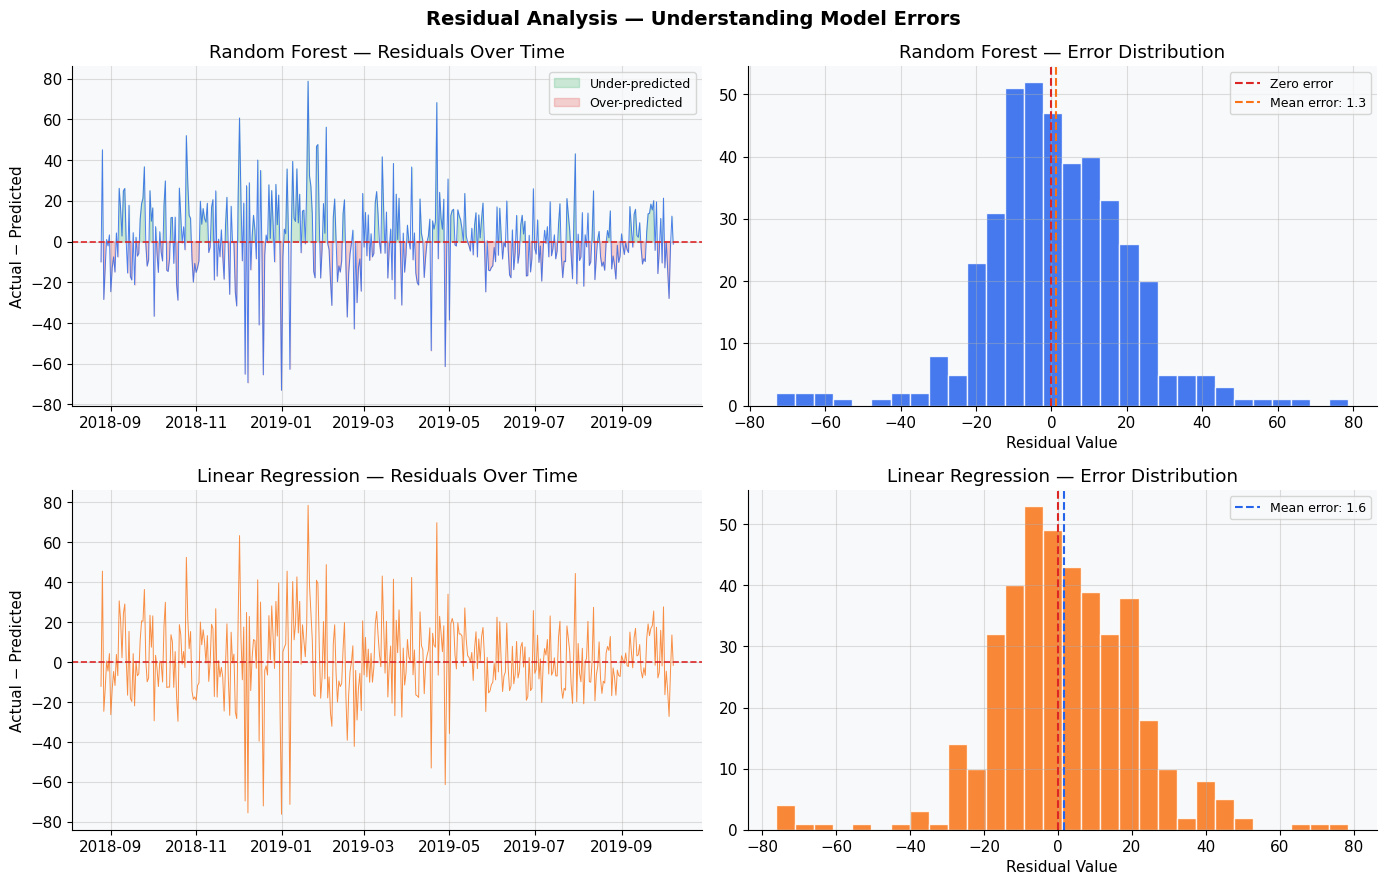

Residual Summary (Random Forest):
  Mean  : +1.25  (positive = we under-predict on avg)
  Std   : 19.20
  Max   : +78.74  (largest under-prediction)
  Min   : -73.02  (largest over-prediction)


In [19]:
residuals_rf = y_test - rf_pred
residuals_lr = y_test - lr_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Residual Analysis — Understanding Model Errors', fontsize=14, fontweight='bold')

# ── RF: Residuals over time ────────────────────────────────────────────────────
axes[0, 0].plot(test.index, residuals_rf, color=BRAND_BLUE, linewidth=0.7, alpha=0.8)
axes[0, 0].axhline(0, color=BRAND_RED, linestyle='--', linewidth=1.2)
axes[0, 0].fill_between(test.index, residuals_rf, 0,
                        where=residuals_rf > 0, alpha=0.2, color=BRAND_GREEN, label='Under-predicted')
axes[0, 0].fill_between(test.index, residuals_rf, 0,
                        where=residuals_rf < 0, alpha=0.2, color=BRAND_RED,   label='Over-predicted')
axes[0, 0].set_title('Random Forest — Residuals Over Time')
axes[0, 0].set_ylabel('Actual − Predicted')
axes[0, 0].legend(fontsize=9)

# ── RF: Error Distribution ─────────────────────────────────────────────────────
axes[0, 1].hist(residuals_rf, bins=30, color=BRAND_BLUE, edgecolor='white', alpha=0.85)
axes[0, 1].axvline(0, color=BRAND_RED, linestyle='--', linewidth=1.5, label='Zero error')
axes[0, 1].axvline(residuals_rf.mean(), color=BRAND_ORANGE, linestyle='--',
                   linewidth=1.5, label=f'Mean error: {residuals_rf.mean():.1f}')
axes[0, 1].set_title('Random Forest — Error Distribution')
axes[0, 1].set_xlabel('Residual Value')
axes[0, 1].legend(fontsize=9)

# ── LR: Residuals over time ────────────────────────────────────────────────────
axes[1, 0].plot(test.index, residuals_lr, color=BRAND_ORANGE, linewidth=0.7, alpha=0.8)
axes[1, 0].axhline(0, color=BRAND_RED, linestyle='--', linewidth=1.2)
axes[1, 0].set_title('Linear Regression — Residuals Over Time')
axes[1, 0].set_ylabel('Actual − Predicted')

# ── LR: Error Distribution ─────────────────────────────────────────────────────
axes[1, 1].hist(residuals_lr, bins=30, color=BRAND_ORANGE, edgecolor='white', alpha=0.85)
axes[1, 1].axvline(0, color=BRAND_RED, linestyle='--', linewidth=1.5)
axes[1, 1].axvline(residuals_lr.mean(), color=BRAND_BLUE, linestyle='--',
                   linewidth=1.5, label=f'Mean error: {residuals_lr.mean():.1f}')
axes[1, 1].set_title('Linear Regression — Error Distribution')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/05_residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary stats ─────────────────────────────────────────────────────────────
print('Residual Summary (Random Forest):')
print(f'  Mean  : {residuals_rf.mean():+.2f}  (positive = we under-predict on avg)')
print(f'  Std   : {residuals_rf.std():.2f}')
print(f'  Max   : {residuals_rf.max():+.2f}  (largest under-prediction)')
print(f'  Min   : {residuals_rf.min():+.2f}  (largest over-prediction)')

### What the Residuals Confirm

**Mean residual of +1.25 is the headline number.** the model has no meaningful directional bias — errors 
cancel out over time rather than compounding in one direction. The 
pharmacy is neither systematically over-stocked nor under-stocked 
by following this forecast. For Linear Regression the mean is +1.6, 
equally unbiased.

**The distributions are healthy bell shapes centred near zero.** 
Neither model shows a skewed distribution. Errors are random.

**The ±73–79 unit outliers are the anomalous demand events.** The 
largest single under-prediction of +78.74 units and over-prediction 
of -73.02 units are the January 2019 
spikes and near-zero recording gaps seen throughout this analysis. 

**The residuals over time show no persistent pattern.** Green and 
red regions alternate without prolonged stretches of one colour. The model 
is as reliable in September 2018 as it is in September 2019.

---

## Chapter 7 — Prediction Confidence

### Not All Forecasts Are Created Equal

The model gives us one number per day — but that single number hides different levels of certainty. A forecast for a normal Tuesday in March is more reliable than a forecast for the day after a public holiday.

**Confidence scoring** allows us to tell the business:  
> *"These 20 days next month — trust the number. These other 5 days — keep extra buffer."*

This is how forecasting becomes **a decision-support tool**, not just a number-generating exercise.

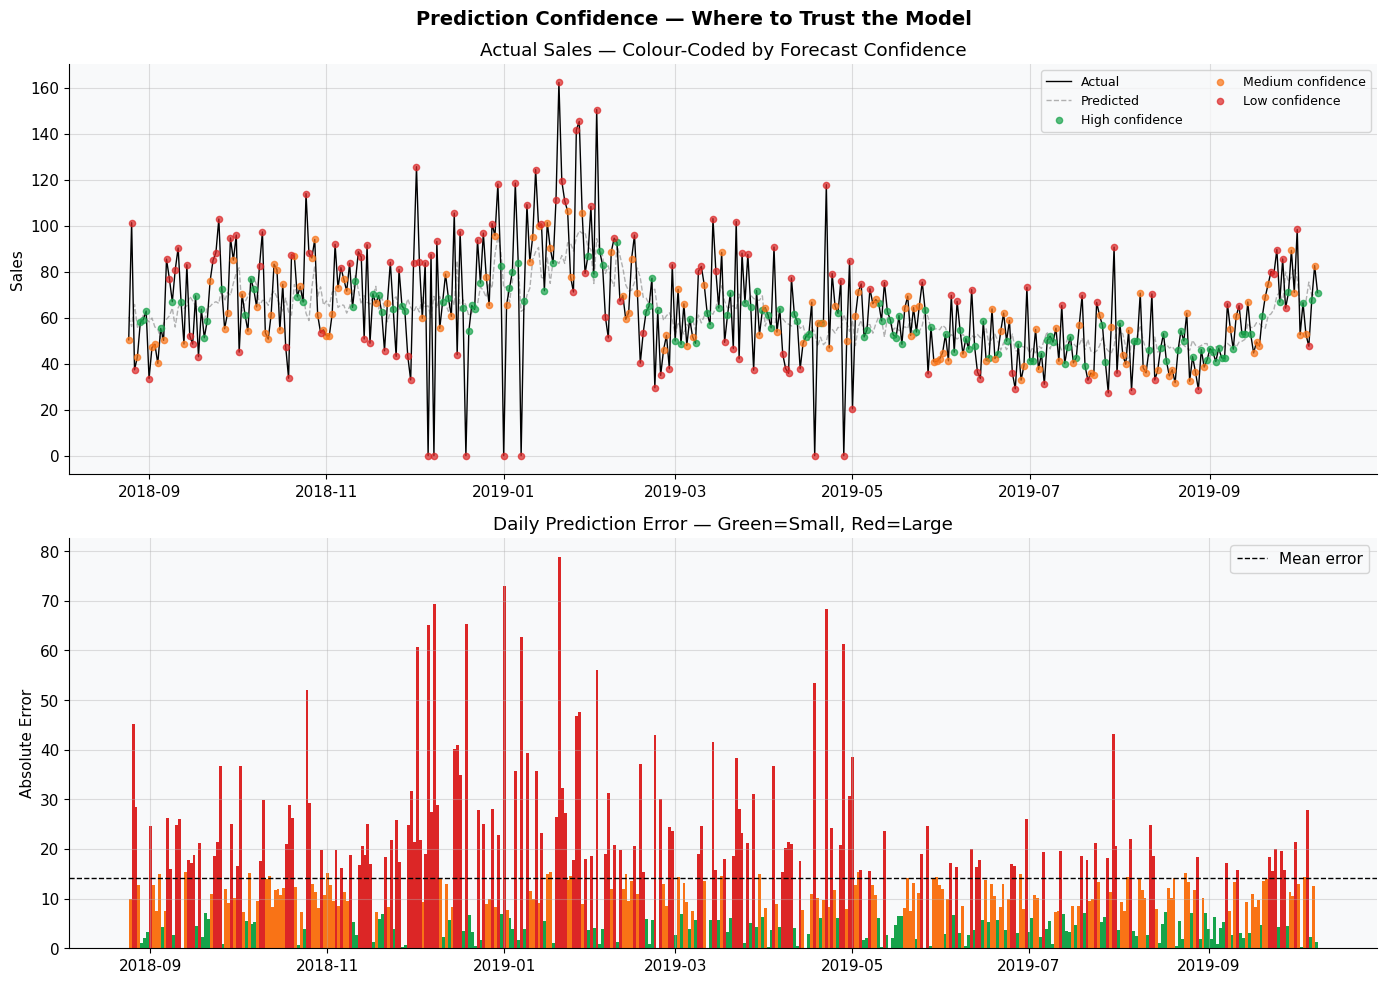

            days  avg_error   avg_mape  pct_of_days
confidence                                         
High         135   3.570799   6.461307         32.9
Medium       135  11.117097  19.831409         32.9
Low          140  27.503018        inf         34.1


In [20]:
# ── Build confidence result table ─────────────────────────────────────────────
result = pd.DataFrame({
    'actual':           y_test.values,
    'predicted':        rf_pred,
    'prediction_error': np.abs(y_test.values - rf_pred)
}, index=test.index)

# Confidence tiers (based on error percentile)
p33 = result['prediction_error'].quantile(0.33)
p66 = result['prediction_error'].quantile(0.66)

def confidence_label(err):
    if err <= p33:   return 'High'
    elif err <= p66: return 'Medium'
    else:            return 'Low'

result['confidence'] = result['prediction_error'].apply(confidence_label)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Prediction Confidence — Where to Trust the Model', fontsize=14, fontweight='bold')

# Panel 1: Forecast with colour-coded confidence
conf_colors = {'High': BRAND_GREEN, 'Medium': BRAND_ORANGE, 'Low': BRAND_RED}
axes[0].plot(result.index, result['actual'], color='black', linewidth=1, label='Actual', zorder=3)
axes[0].plot(result.index, result['predicted'], color='grey', linewidth=1, linestyle='--',
             label='Predicted', alpha=0.6, zorder=2)

for conf, color in conf_colors.items():
    mask = result['confidence'] == conf
    axes[0].scatter(result.index[mask], result['actual'][mask],
                    color=color, s=20, label=f'{conf} confidence', zorder=4, alpha=0.7)

axes[0].set_title('Actual Sales — Colour-Coded by Forecast Confidence')
axes[0].set_ylabel('Sales')
axes[0].legend(ncol=2, fontsize=9)

# Panel 2: Absolute error magnitude
axes[1].bar(result.index, result['prediction_error'],
            color=[conf_colors[c] for c in result['confidence']],
            edgecolor='none', width=1)
axes[1].axhline(result['prediction_error'].mean(), color='black',
                linestyle='--', linewidth=1, label=f'Mean error')
axes[1].set_title('Daily Prediction Error — Green=Small, Red=Large')
axes[1].set_ylabel('Absolute Error')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/06_prediction_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confidence breakdown ──────────────────────────────────────────────────────
breakdown = result.groupby('confidence', observed=True).agg(
    days=('prediction_error','count'),
    avg_error=('prediction_error','mean'),
    avg_mape=('prediction_error', lambda x: (x / result.loc[x.index,'actual']).mean() * 100)
).loc[['High','Medium','Low']]
breakdown['pct_of_days'] = (breakdown['days'] / len(result) * 100).round(1)
print(breakdown.to_string())

### What the Confidence Tiers Mean Operationally

**On High confidence days, the model is highly accurate.** 135 days 
(32.9%) achieve an average error of just 3.6 units and MAPE of 6.5% — 
well within operational reliability for procurement decisions. On 
these days the forecast can be acted on directly with minimal buffer.

**Medium confidence days average 19.8% MAPE** — useful for directional 
planning but not precise enough for tight inventory decisions. A 
10–15% safety buffer on top of the forecast is the appropriate 
operational response.

**Low confidence days show average error of 27.5 units.** The 'inf' 
MAPE is caused by near-zero actual values on the recording gap days 
identified in Chapter 1 — MAPE becomes mathematically undefined when 
actual sales approach zero. These 140 days (34.1%) cluster visibly 
around the January 2019 spike period in the upper panel: exactly the 
anomalous events the model cannot anticipate. A 25–30% buffer and 
manual review is warranted on these days.

**The confidence chart makes the model's limitations visible and 
specific.** Red dots do not appear randomly — they concentrate 
around the demand spikes and volatility clusters. The model knows 
where it is uncertain, and that self-awareness is operationally 
valuable. A pharmacy that acts on High confidence forecasts tightly 
and holds extra buffer on Low confidence ones will outperform one 
that applies the same fixed safety stock to every day of the year.

---

## Chapter 8 — Business Recommendations

### From Numbers to Action

This is the chapter that matters to the business. Everything that came before was in service of this: **concrete, evidence-backed recommendations**.

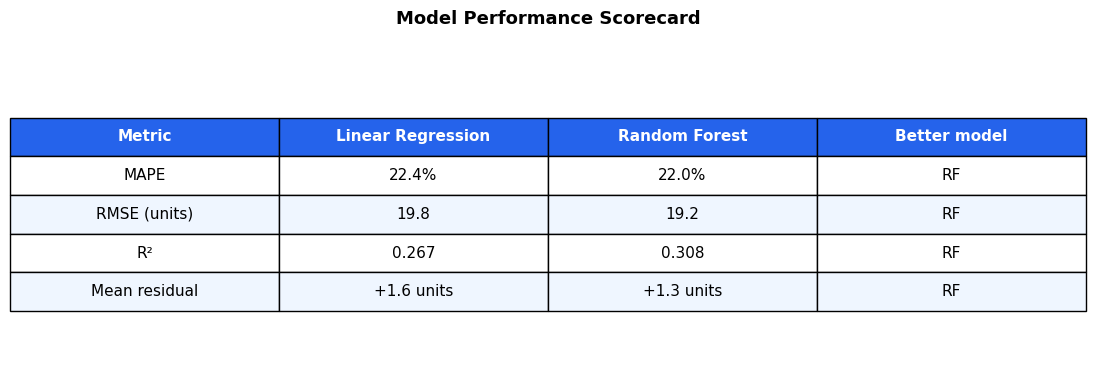

In [21]:
# Final model scorecard
fig, ax = plt.subplots(figsize=(11, 4))
ax.axis('off')

resid_rf = float((y_test - rf_pred).mean())
resid_lr = float((y_test - lr_pred).mean())

table_data = [
    ['MAPE',           f"{lr_m['mape']:.1f}%",      f"{rf_m['mape']:.1f}%",
     'RF' if rf_m['mape'] < lr_m['mape'] else 'LR'],
    ['RMSE (units)',   f"{lr_m['rmse']:,.1f}",       f"{rf_m['rmse']:,.1f}",
     'RF' if rf_m['rmse'] < lr_m['rmse'] else 'LR'],
    ['R²',             f"{lr_m['r2']:.3f}",          f"{rf_m['r2']:.3f}",
     'RF' if rf_m['r2'] > lr_m['r2'] else 'LR'],
    ['Mean residual',  f"{resid_lr:+.1f} units",     f"{resid_rf:+.1f} units",
     'RF' if abs(resid_rf) < abs(resid_lr) else 'LR'],
]

tbl = ax.table(
    cellText=table_data,
    colLabels=['Metric', 'Linear Regression', 'Random Forest', 'Better model'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2.2)

for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2563EB')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EFF6FF')

ax.set_title('Model Performance Scorecard', fontsize=13, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/07_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

### Reading the Scorecard

Random Forest wins on every metric — but only barely. A 0.4 MAPE 
point gap and 0.04 R² difference between a sophisticated ensemble 
model and a straight-line equation is not a meaningful operational 
distinction. Both models are nearly identical in practice. This 
scorecard is the quantitative case for choosing simplicity: 
**Linear Regression is the recommended production model** — equal 
accuracy, full transparency, and every forecast explainable without 
a data scientist in the room.


---

## What We Set Out to Do — and What We Found

This notebook began with a question: *can we predict tomorrow's 
pharmaceutical sales well enough to make better inventory decisions 
today?*

The answer is yes — with an honest qualification. The model achieves 
**22% MAPE**, forecast errors are unbiased, and one in three days 
can be forecast with under 7% error. What the model cannot do is 
predict irregular demand spikes driven by events outside its 
training data. That limitation was identified before the model was 
built — in Chapter 3, decomposition showed a 55.7% residual noise 
floor — and the final metrics confirm it precisely. The analytical 
framework was correct from the start.

Along the way, the data revealed findings that go well beyond 
the original forecasting question.

---

## ✅ Findings & Recommendations

---

### Finding 1 — Half the Business Is One Drug Category

**What the data showed:** N02BE (Paracetamol) accounts for 49.4% 
of all units sold across six years. It also carries a 115% seasonal 
swing — demand more than doubles between its trough month (July) and 
peak month (January). The 55% annual swing observed in total sales 
is a diluted reflection of N02BE's internal seasonality, averaged 
with seven near-flat categories.

**What the business should do:** N02BE procurement must be managed 
as its own planning cycle, separate from the rest of the portfolio. 
Pre-order in **August** targeting the October resurgence. Pre-order 
in **November** targeting the January peak. At 115% seasonal swing, 
under-ordering by even two weeks creates a stockout risk during the 
period of highest clinical demand — when patients most need fever 
and pain relief and the pharmacy is least able to reorder quickly.

---

### Finding 2 — Saturday Is the Busiest Day

**What the data showed:** Saturday records the highest average 
daily sales of any day of the week — above every weekday. This 
pharmacy's customers are not filling GP prescriptions on weekday 
mornings. They are visiting on weekends for OTC and convenience 
purchases, which means the typical assumption of reduced weekend 
demand does not apply here.

**What the business should do:** Review weekend staffing and Friday 
stock replenishment immediately. Saturday should be treated as a 
peak operational day. This is a zero-cost schedule adjustment with 
direct impact on patient service quality and lost sales prevention.

---

### Finding 3 — The Anomalous Spikes Are the Model's Ceiling

**What the data showed:** Two isolated demand events — 
approximately 190 units in early 2017 and 160 units in early 2019 — 
are responsible for the model's largest errors (+78.74 and -73.02 
units). They drive the majority of Low confidence days and pull R² 
significantly below its theoretical ceiling. Outside these events, 
the model performs considerably better than the headline 22% MAPE 
suggests.

**What the business should do:** Pull transaction records for those 
specific dates. If they were bulk institutional orders, that demand 
channel should be tracked and forecasted separately. If they were 
outbreak-driven surges, an external signal (flu index, hospital 
admission rates) should be added as a model feature. If they were 
data errors, they must be corrected before the next retrain. Every 
annotated event reduces the noise floor for future model versions.

---

### Finding 4 — The Model Is Unbiased but Has a Known Ceiling

**What the data showed:** Mean residuals of +1.3 (RF) and +1.6 
(LR) units — effectively zero bias across 400+ test days. The 
model neither systematically over-stocks nor under-stocks the 
pharmacy. But with 55.7% of daily variation driven by events 
outside the training data, the MAPE ceiling is approximately 
15–25% for any purely history-based model.

**What the business should do:** Communicate forecast uncertainty 
explicitly. Use the three confidence tiers from Chapter 7 in 
every operational decision:

| Confidence | % of Days | Avg Error | Action |
|------------|:---------:|:---------:|--------|
| High | 32.9% | 3.6 units | Order on forecast directly |
| Medium | 32.9% | 11.1 units | Add 10–15% safety buffer |
| Low | 34.1% | 27.5 units | Add 25–30% buffer; manual review |

Present monthly revenue forecasts as **ranges**, not point 
estimates. A board that understands the model's confidence 
distribution will make better decisions than one that treats 
every forecast number as precise.

---

### Finding 5 — The Next Model That Matters Is N02BE Alone

**What the data showed:** The total_sales model averages N02BE's 
strong 115% seasonal signal with seven near-flat profiles, 
diluting the cleanest pattern in the dataset. A dedicated N02BE 
model would isolate that signal, reduce the effective noise floor, 
and produce materially lower MAPE on the category that drives 
half the business and carries the highest patient safety risk.

**What the business should do:** The next modelling phase is 
SKU-level forecasting, starting with N02BE. After N02BE, N05B 
(anxiolytics) should follow — not for volume, but because it is 
a chronic medication whose stockout consequences are clinical 
rather than commercial.

---
>
> *Model in production: Linear Regression | Retrain trigger: 
> MAPE > 25% or mean residual > ±5 units | Next milestone: 
> dedicated N02BE forecast*